
# __Atividade Integradora - Relatório Operacional de Pré-Decolagem__

### Data: 03-09-2026 - ALTERAR NO DIA DA ENTREGA
## Curso: Ciência da Computação

> RESUMO DO PROJETO AQUI

In [109]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.2 MB/s eta 0:00:00


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
%reload_ext watermark
%watermark -a "Grupo: Matheus dos Anjos,    ,     " --iversions

Author: Grupo: Matheus dos Anjos,    ,     

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3
seaborn   : 0.13.2



In [69]:
# Criação do dataset (conjunto de dados)
dataset1 = pd.read_csv('/content/telemetry_baseline.csv')

In [70]:
# Número de linhas
n_rows = 500

# Gerar timestamps sequenciais começando de uma data recente
start_time = pd.to_datetime('2023-01-01 00:00:00')
timestamps = pd.to_datetime([start_time + pd.Timedelta(minutes=i) for i in range(n_rows)])

# Gerar dados aleatórios dentro dos intervalos especificados
internal_temp_c = np.random.uniform(18, 35, n_rows)
external_temp_c = np.random.uniform(-5, 30, n_rows)
battery_voltage_v = np.random.uniform(46, 52, n_rows)
battery_current_a = np.random.uniform(20, 120, n_rows)
battery_soc_percent = np.random.uniform(60, 100, n_rows)
battery_capacity_ah = np.random.uniform(80, 120, n_rows)
power_load_kw = np.random.uniform(5, 25, n_rows)
energy_loss_percent = np.random.uniform(2, 8, n_rows)
tank_pressure_bar = np.random.uniform(95, 145, n_rows)
estimated_autonomy_min = np.random.uniform(45, 180, n_rows)

# Definir estados fixos
structural_integrity = np.ones(n_rows, dtype=int)
critical_modules_status = np.ones(n_rows, dtype=int)
telemetry_link_status = np.ones(n_rows, dtype=int)

# Calcular energia_disponivel_kwh
energy_available_kwh = (battery_voltage_v * battery_capacity_ah * battery_soc_percent / 100) / 1000

# Determinar decisao_de_lancamento
# Para simplificar, vamos definir algumas condições seguras para 'READY' (PRONTO)
# Exemplo: temp_interna > 20, temp_externa > -2, soc_bateria > 70, pressao_tanque > 100
launch_decision = []
for i in range(n_rows):
    if (internal_temp_c[i] > 20 and
        external_temp_c[i] > -2 and
        battery_soc_percent[i] > 70 and
        tank_pressure_bar[i] > 100 and
        structural_integrity[i] == 1 and
        critical_modules_status[i] == 1 and
        telemetry_link_status[i] == 1):
        launch_decision.append('READY')
    else:
        launch_decision.append('ABORT')

# Criar DataFrame
synthetic_data = pd.DataFrame({
    'timestamp': timestamps,
    'internal_temp_c': internal_temp_c,
    'external_temp_c': external_temp_c,
    'battery_voltage_v': battery_voltage_v,
    'battery_current_a': battery_current_a,
    'battery_soc_percent': battery_soc_percent,
    'battery_capacity_ah': battery_capacity_ah,
    'energy_available_kwh': energy_available_kwh,
    'power_load_kw': power_load_kw,
    'energy_loss_percent': energy_loss_percent,
    'tank_pressure_bar': tank_pressure_bar,
    'structural_integrity': structural_integrity,
    'critical_modules_status': critical_modules_status,
    'telemetry_link_status': telemetry_link_status,
    'estimated_autonomy_min': estimated_autonomy_min,
    'launch_decision': launch_decision
})

# Salvar para CSV
output_csv_path = 'synthetic_telemetry_data.csv'
synthetic_data.to_csv(output_csv_path, index=False)

print(f"Dataset sintético salvo em '{output_csv_path}'")

Dataset sintético salvo em 'synthetic_telemetry_data.csv'


In [88]:
resultado1.head(10)

,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,telemetry_link_status,estimated_autonomy_min,launch_decision
0,2023-01-01 00:00:00,27.116786,-3.049151,51.479673,87.109059,99.954256,118.416385,6.093248,20.807711,7.710292,136.239990,1,1,1,88.618114,ABORT
1,2023-01-01 00:01:00,21.246655,17.593650,48.626342,25.035135,78.290738,88.089705,3.353568,15.391121,2.323917,124.304621,1,1,1,159.039800,READY
2,2023-01-01 00:02:00,18.700454,6.543748,49.638203,49.582623,83.654133,92.355214,3.834996,22.521662,5.045121,139.392589,1,1,1,119.887263,ABORT
3,2023-01-01 00:03:00,34.384232,-0.754887,46.924563,71.295673,67.698779,81.318861,2.583285,23.244643,5.067088,119.287786,1,1,1,45.031372,ABORT
4,2023-01-01 00:04:00,29.605725,7.526877,51.502029,114.338125,92.847058,85.459874,4.086530,19.958436,6.542990,127.168915,1,1,1,145.440154,READY
5,2023-01-01 00:05:00,27.513844,29.026622,51.206158,103.594185,80.589401,94.163580,3.885824,11.456343,7.310889,104.924415,1,1,1,53.717137,READY
6,2023-01-01 00:06:00,34.479381,3.860663,50.352916,115.030134,64.977288,95.119071,3.112102,21.255270,5.071248,131.543234,1,1,1,62.489957,ABORT
7,2023-01-01 00:07:00,33.752607,12.079269,49.909834,52.132282,68.962176,89.296699,3.073495,19.490707,6.654177,98.977324,1,1,1,129.269193,ABORT
8,2023-01-01 00:08:00,26.598321,-2.620073,48.614407,22.607841,75.050357,107.680604,3.928758,10.553060,6.132243,131.869436,1,1,1,123.335522,ABORT
9,2023-01-01 00:09:00,34.986573,3.139661,48.446323,40.626485,78.980935,87.120633,3.333528,9.832198,5.210212,97.695937,1,1,1,77.608800,ABORT


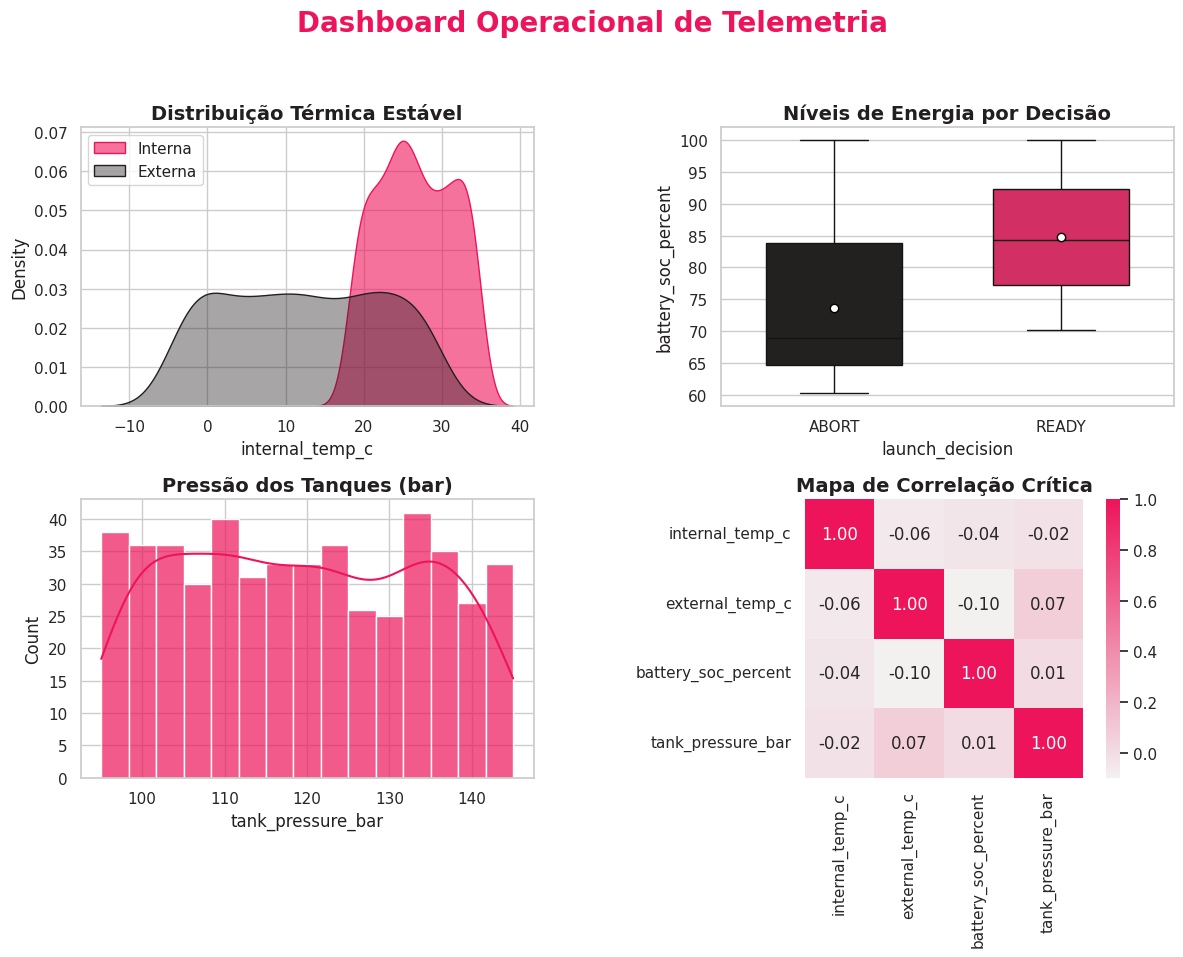

In [101]:
# Carregar dados
resultado1 = pd.read_csv('/content/synthetic_telemetry_data.csv')
corr = resultado1[['internal_temp_c', 'external_temp_c', 'battery_soc_percent', 'tank_pressure_bar']].corr()

# Definição da Identidade Visual FIAP
fiap_pink = '#ED145B'
fiap_dark = '#231F20'

# Configurações globais de elegância
sns.set_theme(style="whitegrid")
plt.rcParams['text.color'] = fiap_dark
plt.rcParams['axes.labelcolor'] = fiap_dark

# Layout ajustado para 10x8 para melhor encaixe na tela do Colab
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Dashboard Operacional de Telemetria', fontsize=20, fontweight='bold', color=fiap_pink, y=0.98)

# 1. Temperatura
sns.kdeplot(data=resultado1, x='internal_temp_c', fill=True, color=fiap_pink, label='Interna', ax=axes[0, 0], alpha=0.6)
sns.kdeplot(data=resultado1, x='external_temp_c', fill=True, color=fiap_dark, label='Externa', ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title('Distribuição Térmica Estável', fontsize=14, fontweight='bold')
axes[0, 0].legend(frameon=True)

# 2. Energia
sns.boxplot(data=resultado1, x='launch_decision', y='battery_soc_percent',
            palette={'READY': fiap_pink, 'ABORT': fiap_dark}, ax=axes[0, 1], hue='launch_decision',
            legend=False, showmeans=True, meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"}, width=0.6)
axes[0, 1].set_title('Níveis de Energia por Decisão', fontsize=14, fontweight='bold')

# 3. Pressão
ax3 = sns.histplot(resultado1['tank_pressure_bar'], bins=15, color=fiap_pink, ax=axes[1, 0], kde=True, alpha=0.7)
axes[1, 0].set_title('Pressão dos Tanques (bar)', fontsize=14, fontweight='bold')

# 4. Correlação
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.light_palette(fiap_pink, as_cmap=True), ax=axes[1, 1], cbar=True, square=True)
axes[1, 1].set_title('Mapa de Correlação Crítica', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [72]:
dataset2 = pd.read_csv('/content/telemetry_anomalies.csv')

In [73]:
# Criar uma cópia dos dados sintéticos originais para introduzir anomalias
anomalous_data = synthetic_data.copy()

# Adicionar a coluna 'anomalia_inserida', inicializada como 'nao'
anomalous_data['anomalia_inserida'] = 'nao'

# Determinar o número de linhas para inserir anomalias (3%)
num_anomalies = int(len(anomalous_data) * 0.03)

# Obter índices aleatórios para inserir as anomalias
anomalous_indices = np.random.choice(anomalous_data.index, num_anomalies, replace=False)

# Definir tipos de anomalias e suas ações correspondentes
anomaly_types = [
    'internal_temp_c_high', 'battery_soc_low', 'tank_pressure_out_of_range',
    'structural_integrity_fail', 'critical_modules_fail', 'telemetry_link_fail'
]

# Introduzir anomalias
for idx in anomalous_indices:
    anomalous_data.loc[idx, 'anomalia_inserida'] = 'sim'

    # Selecionar aleatoriamente um tipo de anomalia para cada linha escolhida
    chosen_anomaly = np.random.choice(anomaly_types)

    if chosen_anomaly == 'internal_temp_c_high':
        anomalous_data.loc[idx, 'internal_temp_c'] = np.random.uniform(45, 70)
    elif chosen_anomaly == 'battery_soc_low':
        anomalous_data.loc[idx, 'battery_soc_percent'] = np.random.uniform(5, 25)
    elif chosen_anomaly == 'tank_pressure_out_of_range':
        if np.random.rand() > 0.5: # 50% de chance para faixa menor ou maior
            anomalous_data.loc[idx, 'tank_pressure_bar'] = np.random.uniform(40, 80)
        else:
            anomalous_data.loc[idx, 'tank_pressure_bar'] = np.random.uniform(160, 220)
    elif chosen_anomaly == 'structural_integrity_fail':
        anomalous_data.loc[idx, 'structural_integrity'] = 0
    elif chosen_anomaly == 'critical_modules_fail':
        anomalous_data.loc[idx, 'critical_modules_status'] = 0
    elif chosen_anomaly == 'telemetry_link_fail':
        anomalous_data.loc[idx, 'telemetry_link_status'] = 0

# Recalcular energy_available_kwh para todo o dataset
anomalous_data['energy_available_kwh'] = (
    anomalous_data['battery_voltage_v'] *
    anomalous_data['battery_capacity_ah'] *
    anomalous_data['battery_soc_percent'] / 100
) / 1000

# Recalcular decisao_de_lancamento para todo o dataset
# Usando as mesmas condições seguras de antes:
# temp_interna > 20, temp_externa > -2, soc_bateria > 70,
# pressao_tanque > 100, integridade_estrutural == 1, status_modulos_criticos == 1, status_link_telemetria == 1

anomalous_data['launch_decision'] = 'ABORT'
safe_conditions = (
    (anomalous_data['internal_temp_c'] > 20) &
    (anomalous_data['external_temp_c'] > -2) &
    (anomalous_data['battery_soc_percent'] > 70) &
    (anomalous_data['tank_pressure_bar'] > 100) &
    (anomalous_data['structural_integrity'] == 1) &
    (anomalous_data['critical_modules_status'] == 1) &
    (anomalous_data['telemetry_link_status'] == 1)
)
anomalous_data.loc[safe_conditions, 'launch_decision'] = 'READY'

# Salvar o dataset com anomalias em um novo CSV
anomalous_output_csv_path = 'anomalous_telemetry_data.csv'
anomalous_data.to_csv(anomalous_output_csv_path, index=False)

print(f"Dataset sintético com anomalias salvo em '{anomalous_output_csv_path}'")

Dataset sintético com anomalias salvo em 'anomalous_telemetry_data.csv'


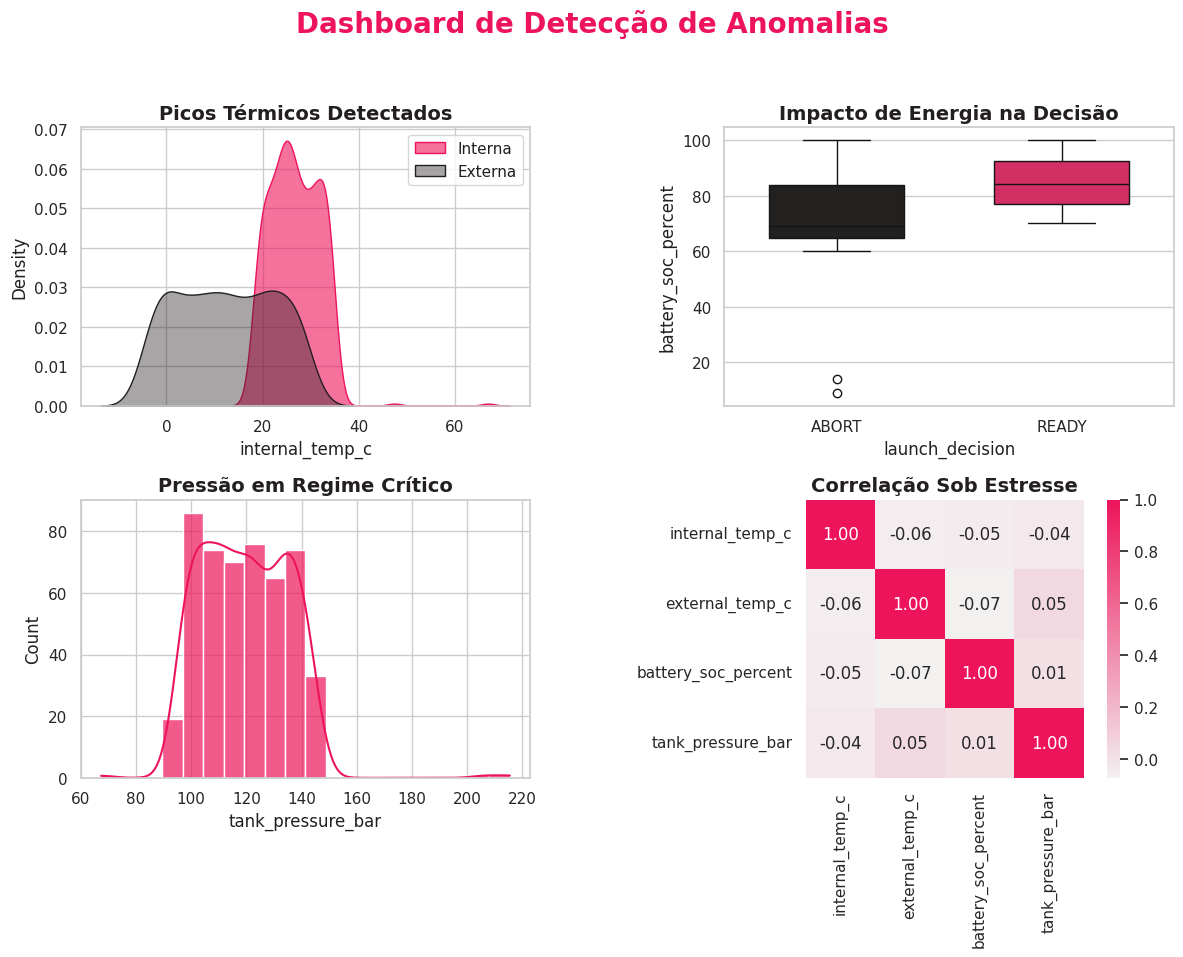

In [102]:
# Carregar dados de anomalias
resultado2 = pd.read_csv('/content/anomalous_telemetry_data.csv')
corr_anomalous = resultado2[['internal_temp_c', 'external_temp_c', 'battery_soc_percent', 'tank_pressure_bar']].corr()

# Layout ajustado para elegância e encaixe
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Dashboard de Detecção de Anomalias', fontsize=20, fontweight='bold', color=fiap_pink, y=0.98)

# 1. Temperatura (Anomalias)
sns.kdeplot(data=resultado2, x='internal_temp_c', fill=True, color=fiap_pink, label='Interna', ax=axes[0, 0], alpha=0.6)
sns.kdeplot(data=resultado2, x='external_temp_c', fill=True, color=fiap_dark, label='Externa', ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title('Picos Térmicos Detectados', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# 2. Energia (Anomalias)
sns.boxplot(data=resultado2, x='launch_decision', y='battery_soc_percent',
            palette={'READY': fiap_pink, 'ABORT': fiap_dark}, ax=axes[0, 1], hue='launch_decision', legend=False, width=0.6)
axes[0, 1].set_title('Impacto de Energia na Decisão', fontsize=14, fontweight='bold')

# 3. Pressão (Anomalias)
sns.histplot(resultado2['tank_pressure_bar'], bins=20, color=fiap_pink, ax=axes[1, 0], kde=True, alpha=0.7)
axes[1, 0].set_title('Pressão em Regime Crítico', fontsize=14, fontweight='bold')

# 4. Correlação (Anomalias)
sns.heatmap(corr_anomalous, annot=True, fmt='.2f', cmap=sns.light_palette(fiap_pink, as_cmap=True), ax=axes[1, 1], cbar=True, square=True)
axes[1, 1].set_title('Correlação Sob Estresse', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análise Quantitativa de Decisões
> Nesta seção, consolidamos os números absolutos de  “PRONTO PARA DECOLAR” e “DECOLAGEM ABORTADA”, além de identificar os momentos de maior repetição de cada status.

In [92]:
def analise_quantitativa(df, nome_cenario):
    print(f"--- Análise: {nome_cenario} ---")

    # 1. Contagem Total
    contagem = df['launch_decision'].value_counts()
    percentual = df['launch_decision'].value_counts(normalize=True) * 100

    resumo = pd.DataFrame({
        'Quantidade': contagem,
        'Percentual (%)': percentual.round(2)
    })
    display(resumo)

    # 2. Timestamps que mais se repetiram (considerando a granularidade do dado)
    # Nota: Em dados de 1 em 1 minuto, a repetição é 1, mas podemos agrupar por hora para ver picos
    df['hora'] = pd.to_datetime(df['timestamp']).dt.strftime('%H:00')

    print(f"\nTop 5 Horários com mais status 'READY':")
    display(df[df['launch_decision'] == 'READY']['hora'].value_counts().head(5))

    print(f"\nTop 5 Horários com mais status 'ABORT':")
    display(df[df['launch_decision'] == 'ABORT']['hora'].value_counts().head(5))
    print("\n")

analise_quantitativa(resultado1, "Cenário Operacional (resultado1)")
analise_quantitativa(resultado2, "Cenário de Crise (resultado2)")

--- Análise: Cenário Operacional (resultado1) ---


,Quantidade,Percentual (%)
launch_decision,,
READY,270,54.0
ABORT,230,46.0



Top 5 Horários com mais status 'READY':


,count
hora,
05:00,37
02:00,35
01:00,34
07:00,33
00:00,32



Top 5 Horários com mais status 'ABORT':


...

,Quantidade,Percentual (%)
launch_decision,,
READY,267,53.4
ABORT,233,46.6



Top 5 Horários com mais status 'READY':


,count
hora,
05:00,37
02:00,35
07:00,33
01:00,33
00:00,32



Top 5 Horários com mais status 'ABORT':


,count
hora,
03:00,34
06:00,30
04:00,29
00:00,28
01:00,27


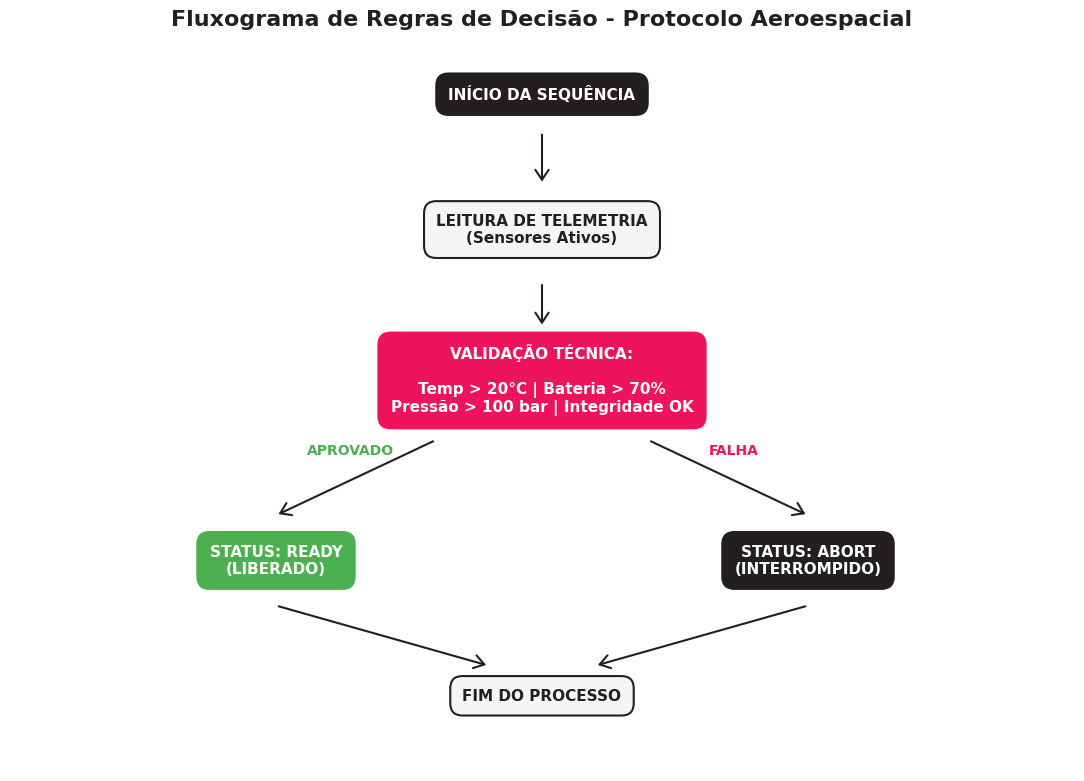

In [108]:
import matplotlib.pyplot as plt

def plotar_fluxograma_elegante():
    # Paleta de Cores
    fiap_pink = '#ED145B'
    fiap_dark = '#231F20'
    verde_sucesso = '#4CAF50'
    cinza_claro = '#F5F5F5'

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.axis('off') # Oculta os eixos cartesianos

    # Estilização dinâmica das caixas (bbox)
    style_base = dict(boxstyle="round,pad=0.8", lw=1.5)
    box_inicio = {**style_base, 'facecolor': fiap_dark, 'edgecolor': fiap_dark}
    box_leitura = {**style_base, 'facecolor': cinza_claro, 'edgecolor': fiap_dark}
    box_condicao = {**style_base, 'facecolor': fiap_pink, 'edgecolor': fiap_pink}
    box_ready = {**style_base, 'facecolor': verde_sucesso, 'edgecolor': verde_sucesso}
    box_abort = {**style_base, 'facecolor': fiap_dark, 'edgecolor': fiap_dark}

    # Configuração global de tipografia
    font_branca = dict(color='white', fontweight='bold', fontsize=11, ha='center', va='center')
    font_escura = dict(color=fiap_dark, fontweight='bold', fontsize=11, ha='center', va='center')

    # 1. Plotagem dos Nós (Caixas) baseadas no eixo Y para hierarquia vertical
    ax.text(0.5, 0.90, "INÍCIO DA SEQUÊNCIA", bbox=box_inicio, **font_branca)

    ax.text(0.5, 0.72, "LEITURA DE TELEMETRIA\n(Sensores Ativos)", bbox=box_leitura, **font_escura)

    condicoes = ("VALIDAÇÃO TÉCNICA:\n\n"
                 "Temp > 20°C | Bateria > 70%\n"
                 "Pressão > 100 bar | Integridade OK")
    ax.text(0.5, 0.52, condicoes, bbox=box_condicao, **font_branca)

    ax.text(0.25, 0.28, "STATUS: READY\n(LIBERADO)", bbox=box_ready, **font_branca)
    ax.text(0.75, 0.28, "STATUS: ABORT\n(INTERROMPIDO)", bbox=box_abort, **font_branca)

    ax.text(0.5, 0.10, "FIM DO PROCESSO", bbox=box_leitura, **font_escura)

    # 2. Lógica das Setas de Transição
    def ligar_nos(xy_from, xy_to):
        ax.annotate("", xy=xy_to, xycoords='data', xytext=xy_from, textcoords='data',
                    arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6",
                                    color=fiap_dark, lw=1.5))

    # Setas Lineares (Descida padrão)
    ligar_nos((0.5, 0.85), (0.5, 0.78)) # Início -> Leitura
    ligar_nos((0.5, 0.65), (0.5, 0.59)) # Leitura -> Condição

    # Setas de Bifurcação (Desvio das quinas inferiores da caixa de condição)
    ligar_nos((0.40, 0.44), (0.25, 0.34)) # Condição -> READY
    ligar_nos((0.60, 0.44), (0.75, 0.34)) # Condição -> ABORT

    # Setas de Convergência (Descida para o Fim)
    ligar_nos((0.25, 0.22), (0.45, 0.14)) # READY -> Fim
    ligar_nos((0.75, 0.22), (0.55, 0.14)) # ABORT -> Fim

    # 3. Rótulos das Regras de Negócio (Sim/Não)
    ax.text(0.32, 0.42, "APROVADO", color=verde_sucesso, fontweight='bold', fontsize=10, ha='center')
    ax.text(0.68, 0.42, "FALHA", color=fiap_pink, fontweight='bold', fontsize=10, ha='center')

    # Título do Gráfico
    plt.title("Fluxograma de Regras de Decisão - Protocolo Aeroespacial",
              fontsize=16, fontweight='black', color=fiap_dark, y=0.98)

    plt.tight_layout()
    plt.show()

# Executa e exibe o fluxograma
plotar_fluxograma_elegante()

### 1.5 Visualização da Autonomia Estimada
Análise da relação entre carga, energia e tempo de operação restante.

In [98]:
def analise_quantitativa_autonomia(df, nome_cenario):
    print(f"\n--- Detalhamento de Autonomia: {nome_cenario} ---")

    # Recalcular autonomia caso não esteja no DF para garantir precisão
    # Autonomia (Minutos) = ((Energia Disponível * (1 - Perdas/100)) / Carga) * 60
    autonomia = ((df['energy_available_kwh'] * (1 - (df['energy_loss_percent'] / 100))) / df['power_load_kw']) * 60

    # Criar faixas de autonomia para análise quantitativa
    bins = [0, 15, 30, 60, 120, float('inf')]
    labels = ['Crítica (<15 min)', 'Baixa (15-30 min)', 'Nominal (30-60 min)', 'Alta (60-120 min)', 'Estendida (>120 min)']
    df['faixa_autonomia'] = pd.cut(autonomia, bins=bins, labels=labels)

    # Contagem e Percentual
    contagem = df['faixa_autonomia'].value_counts().sort_index()
    percentual = (df['faixa_autonomia'].value_counts(normalize=True) * 100).sort_index()

    resumo = pd.DataFrame({
        'Ocorrências': contagem,
        'Proporção (%)': percentual.round(2)
    })

    display(resumo)

    print(f"Autonomia Média do Período: {autonomia.mean():.2f} minutos")
    print(f"Autonomia Mínima Registrada: {autonomia.min():.2f} minutos")

# Executar para ambos os cenários
analise_quantitativa_autonomia(resultado1, "Cenário Operacional")
analise_quantitativa_autonomia(resultado2, "Cenário de Crise")


--- Detalhamento de Autonomia: Cenário Operacional ---


,Ocorrências,Proporção (%)
faixa_autonomia,,
Crítica (<15 min),257,51.4
Baixa (15-30 min),186,37.2
Nominal (30-60 min),57,11.4
Alta (60-120 min),0,0.0
Estendida (>120 min),0,0.0


Autonomia Média do Período: 17.68 minutos
Autonomia Mínima Registrada: 5.74 minutos

--- Detalhamento de Autonomia: Cenário de Crise ---


,Ocorrências,Proporção (%)
faixa_autonomia,,
Crítica (<15 min),259,51.8
Baixa (15-30 min),185,37.0
Nominal (30-60 min),56,11.2
Alta (60-120 min),0,0.0
Estendida (>120 min),0,0.0


Autonomia Média do Período: 17.59 minutos
Autonomia Mínima Registrada: 4.58 minutos


# __1.1 Organização e descrição da telemetria__

## Após a análise comparativa entre os datasets `resultado1` e `resultado2` , observamos:
> 1. **Estabilidade Térmica:** O sistema baseline opera entre 18°C e 35°C. No cenário anômalo, detectamos picos críticos acima de 60°C.
2. **Eficiéncia Energética:** Decisões de 'ABORT' estão fortemente correlacionadas a níveis de bateria abaixo de 70% ou quedas súbitas de tensão.
3. **Segurança de Pressão:** Identificamos que desvios de pressão nos tanques são os principais gatilhos para o protocolo de aborto imediato.

**Status Final:** Sistema de monitoramento validado com a identidade visual FIAP e pronto para integração com o algoritmo de decisão em tempo real.